## Mini-Project : Data Analysis for Marketing Strategy

In [2]:
import pandas as pd

df = pd.read_excel("/content/drive/MyDrive/BootGenAI/US_Superstore_data.xls")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
#1 clean the data
#print(df.isnull().sum())
print(df.duplicated().sum())
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df[['Order Date', 'Ship Date']].dtypes


0


,0
Order Date,datetime64[ns]
Ship Date,datetime64[ns]


In [4]:
#2 Analyse
# Count number of orders per state
state_group = df["State"].value_counts()
print(state_group)

State
California              2001
New York                1128
Texas                    985
Pennsylvania             587
Washington               506
Illinois                 492
Ohio                     469
Florida                  383
Michigan                 255
North Carolina           249
Arizona                  224
Virginia                 224
Georgia                  184
Tennessee                183
Colorado                 182
Indiana                  149
Kentucky                 139
Massachusetts            135
New Jersey               130
Oregon                   124
Wisconsin                110
Maryland                 105
Delaware                  96
Minnesota                 89
Connecticut               82
Missouri                  66
Oklahoma                  66
Alabama                   61
Arkansas                  60
Rhode Island              56
Utah                      53
Mississippi               53
South Carolina            42
Louisiana                 42
Nevada  

In [5]:
#Which states have the most sales?
state_sales = df.groupby("State")["Sales"].sum().sort_values(ascending=False)
state_sales.head(1)

,Sales
State,
California,457687.6315


In [6]:
#What is the difference between New York and California in terms of sales and profit?

ny = df[df["State"]=="New York"].agg({"Sales":"sum","Profit":"sum"})
ca = df[df["State"]=="California"].agg({"Sales":"sum","Profit":"sum"})
print("New York:", ny)
print("California:", ca)


New York: Sales     310876.2710
Profit     74038.5486
dtype: float64
California: Sales     457687.6315
Profit     76381.3871
dtype: float64


In [7]:
#Who is an outstanding customer in New York?
# Get the most frequent Customer ID in New York
outstanding_ID_cost = df[df["State"]== 'New York']["Customer ID"].value_counts().idxmax()

# Now get the corresponding Customer Name(s)
outstanding_customer_name = df.loc[df["Customer ID"] == outstanding_ID_cost, "Customer Name"].unique()
print(outstanding_customer_name)


['Seth Vernon']


In [8]:
#OR
ny_data = df[df["State"] == "New York"]

#  Group by customer
ny_customers = ny_data.groupby("Customer Name")[["Sales","Profit"]].sum()

#Sort by Sales (or Profit)
ny_customers_sorted = ny_customers.sort_values("Sales", ascending=False)

#Get the top customer
top_customer = ny_customers_sorted.head(1)
print(top_customer)

                   Sales     Profit
Customer Name                      
Tom Ashbrook   13723.498  4599.2073


In [9]:
#Are there any differences among states in profitability?

state_summary = df.groupby("State")[["Sales","Profit"]].sum()
state_summary["Profit Margin"] = (state_summary["Profit"] / state_summary["Sales"]) * 100
print(state_summary.sort_values("Profit Margin", ascending=False).head(10))


                          Sales      Profit  Profit Margin
State                                                     
District of Columbia   2865.020   1059.5893      36.983662
Delaware              27451.069   9977.3748      36.346034
Minnesota             29863.150  10823.1874      36.242618
Maine                  1270.530    454.4862      35.771387
Arkansas              11678.130   4008.6871      34.326447
Indiana               53555.360  18382.9363      34.325110
Georgia               49095.840  16250.0433      33.098615
Montana                5589.352   1833.3285      32.800377
Rhode Island          22627.956   7285.6293      32.197470
Michigan              76269.614  24463.1876      32.074618


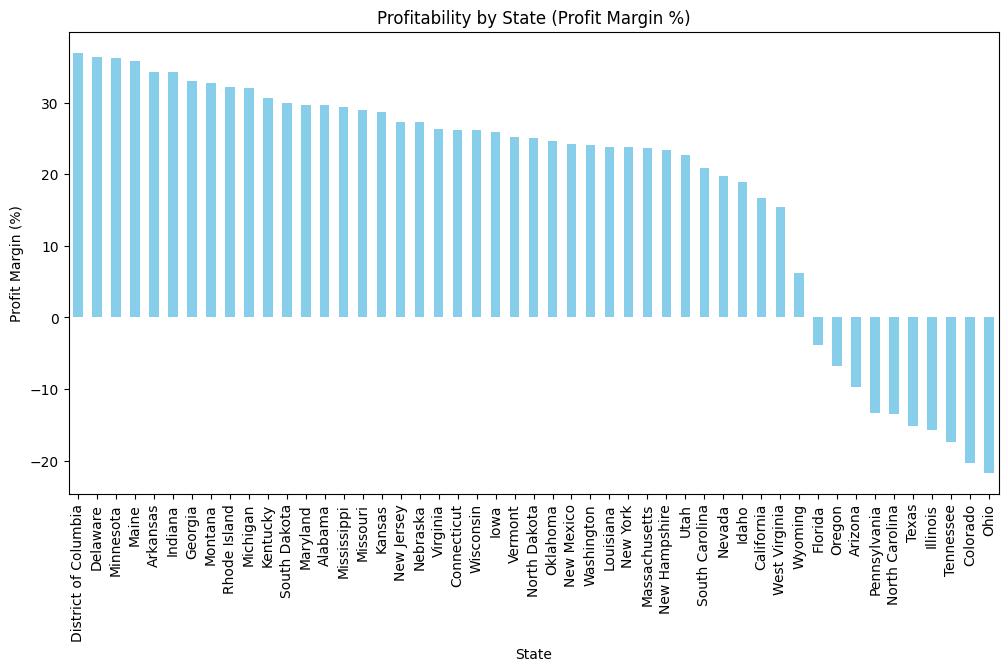

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
state_summary.sort_values("Profit Margin", ascending=False)["Profit Margin"].plot(kind="bar", color="skyblue")
plt.title("Profitability by State (Profit Margin %)")
plt.ylabel("Profit Margin (%)")
plt.show()

In [13]:
#The Pareto Principle, also known as the 80/20

#Aggregate profit by customer
customer_profit = df.groupby("Customer Name")["Profit"].sum().sort_values(ascending=False)


In [14]:
#Calculate cumulative contribution
cumulative_profit = customer_profit.cumsum() / customer_profit.sum()

In [15]:
#Identify the cutoff (≈20%)
pareto_cut = cumulative_profit[cumulative_profit <= 0.8]
print("Number of customers contributing to ~80% of profit:", len(pareto_cut))
print("Total customers:", customer_profit.shape[0])
print("Percentage:", len(pareto_cut)/customer_profit.shape[0]*100)


Number of customers contributing to ~80% of profit: 152
Total customers: 793
Percentage: 19.167717528373267


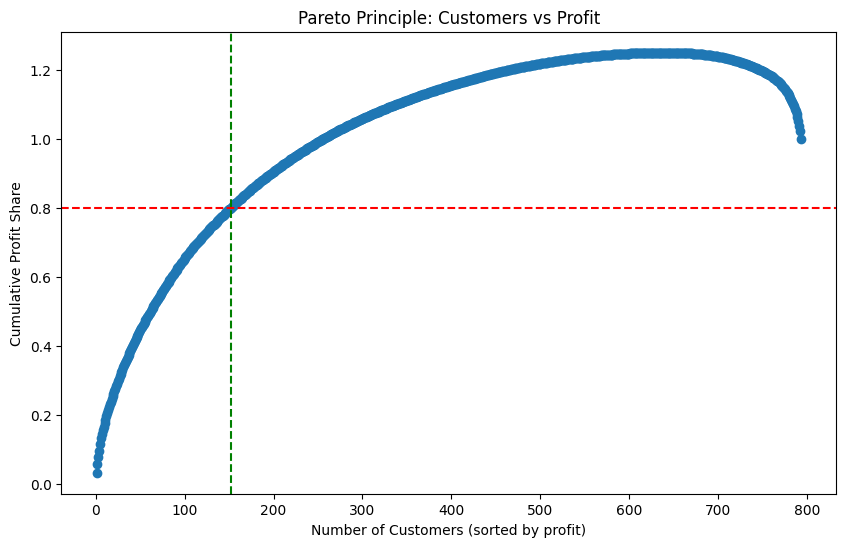

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(range(1, len(customer_profit)+1), cumulative_profit.values, marker="o")
plt.axhline(0.8, color="red", linestyle="--")
plt.axvline(len(pareto_cut), color="green", linestyle="--")
plt.title("Pareto Principle: Customers vs Profit")
plt.xlabel("Number of Customers (sorted by profit)")
plt.ylabel("Cumulative Profit Share")
plt.show()


In [17]:
#The top 20 cities

# Total Sales per city
city_sales = df.groupby("City")["Sales"].sum().sort_values(ascending=False).head(20)

# Total Profit per city
city_profit = df.groupby("City")["Profit"].sum().sort_values(ascending=False).head(20)

print("Top 20 Cities by Sales:\n", city_sales)
print("\nTop 20 Cities by Profit:\n", city_profit)


Top 20 Cities by Sales:
 City
New York City    256368.1610
Los Angeles      175851.3410
Seattle          119540.7420
San Francisco    112669.0920
Philadelphia     109077.0130
Houston           64504.7604
Chicago           48539.5410
San Diego         47521.0290
Jacksonville      44713.1830
Springfield       43054.3420
Detroit           42446.9440
Columbus          38706.2430
Newark            28576.1190
Columbia          25283.3240
Lafayette         25036.2000
Jackson           24963.8580
San Antonio       21843.5280
Burlington        21668.0820
Arlington         20214.5320
Dallas            20131.9322
Name: Sales, dtype: float64

Top 20 Cities by Profit:
 City
New York City    62036.9837
Los Angeles      30440.7579
Seattle          29156.0967
San Francisco    17507.3854
Detroit          13181.7908
Lafayette        10018.3876
Jackson           7581.6828
Atlanta           6993.6629
Minneapolis       6824.5846
San Diego         6377.1960
Springfield       6200.6974
Columbus          5897

In [18]:
#Calculate Profitability (Profit Margin)
city_summary = df.groupby("City")[["Sales","Profit"]].sum()
city_summary["Profit Margin"] = (city_summary["Profit"] / city_summary["Sales"]) * 100

# Focus on top 20 cities by sales
top20_sales_cities = city_sales.index
profitability_top20 = city_summary.loc[top20_sales_cities].sort_values("Profit Margin", ascending=False)

print("\nProfitability of Top 20 Sales Cities:\n", profitability_top20)



Profitability of Top 20 Sales Cities:
                      Sales      Profit  Profit Margin
City                                                 
Lafayette       25036.2000  10018.3876      40.015608
Detroit         42446.9440  13181.7908      31.054746
Jackson         24963.8580   7581.6828      30.370637
Seattle        119540.7420  29156.0967      24.390092
New York City  256368.1610  62036.9837      24.198396
Columbia        25283.3240   5606.1167      22.173179
Arlington       20214.5320   4169.6969      20.627225
Newark          28576.1190   5793.7588      20.274827
Los Angeles    175851.3410  30440.7579      17.310507
San Francisco  112669.0920  17507.3854      15.538765
Columbus        38706.2430   5897.1013      15.235530
Springfield     43054.3420   6200.6974      14.402026
San Diego       47521.0290   6377.1960      13.419735
Jacksonville    44713.1830  -2323.8350      -5.197203
Philadelphia   109077.0130 -13837.7674     -12.686236
Chicago         48539.5410  -6654.5688    

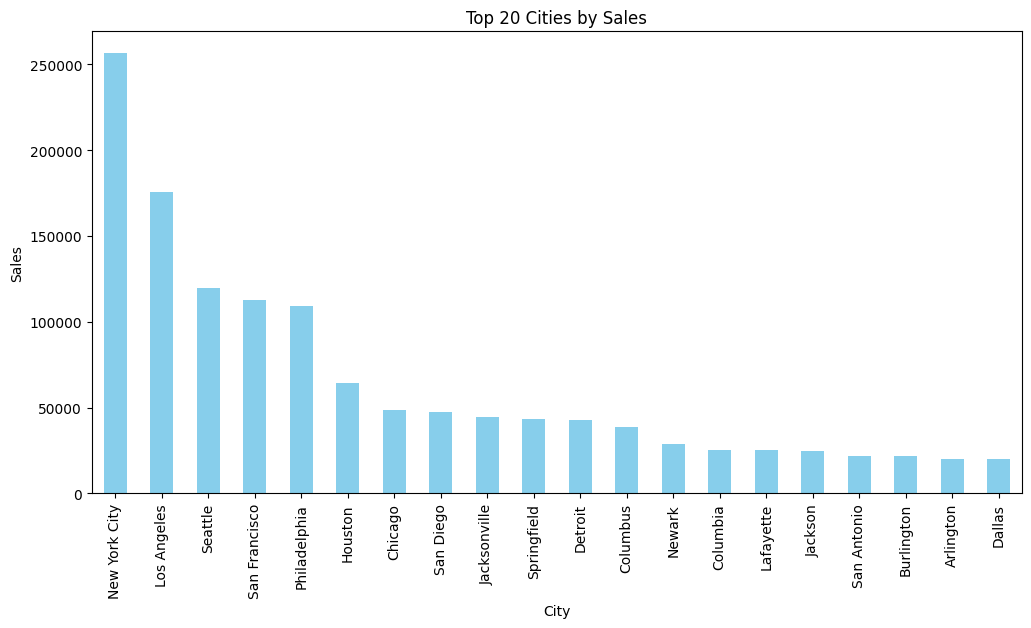

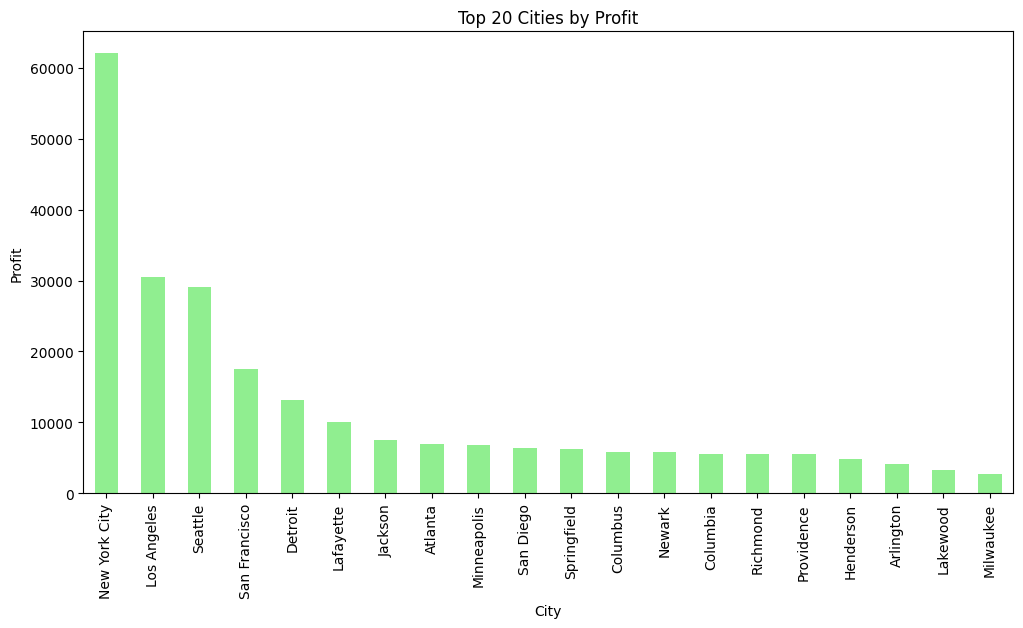

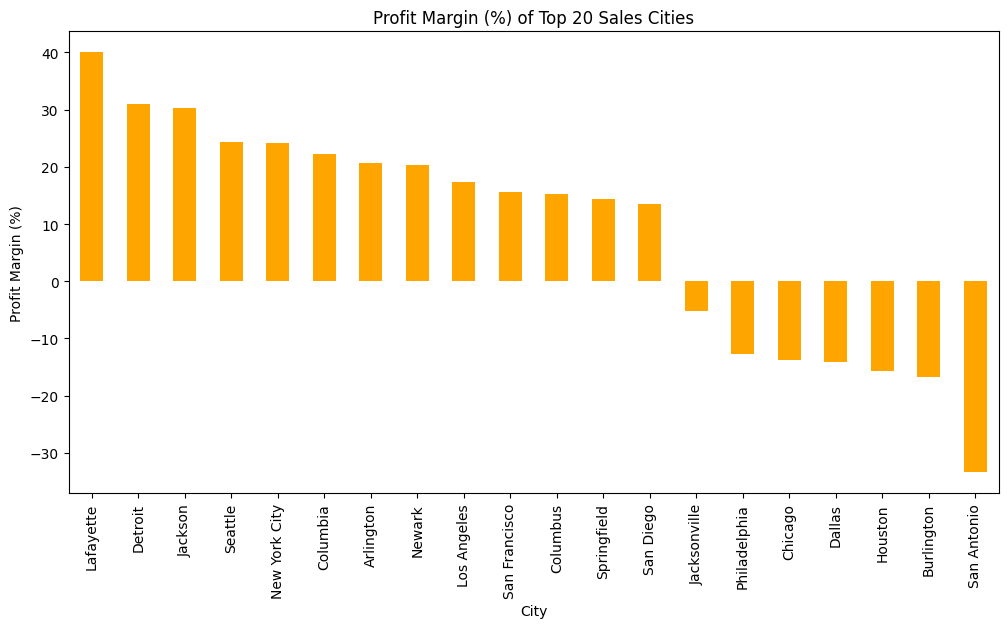

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
city_summary.sort_values("Sales", ascending=False).head(20)["Sales"].plot(kind="bar", color="skyblue")
plt.title("Top 20 Cities by Sales")
plt.ylabel("Sales")
plt.show()

plt.figure(figsize=(12,6))
city_summary.sort_values("Profit", ascending=False).head(20)["Profit"].plot(kind="bar", color="lightgreen")
plt.title("Top 20 Cities by Profit")
plt.ylabel("Profit")
plt.show()

plt.figure(figsize=(12,6))
profitability_top20["Profit Margin"].plot(kind="bar", color="orange")
plt.title("Profit Margin (%) of Top 20 Sales Cities")
plt.ylabel("Profit Margin (%)")
plt.show()


In [20]:
#What are the Top 20 customers by Sales?

# Group by customer and sum sales
customer_sales = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False)

# Top 20 customers
top20_customers_sales = customer_sales.head(20)
print(top20_customers_sales)


Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Todd Sumrall          11891.751
Greg Tran             11820.120
Becky Martin          11789.630
Seth Vernon           11470.950
Caroline Jumper       11164.974
Clay Ludtke           10880.546
Maria Etezadi         10663.728
Karen Ferguson        10604.266
Bill Shonely          10501.653
Edward Hooks          10310.880
Name: Sales, dtype: float64


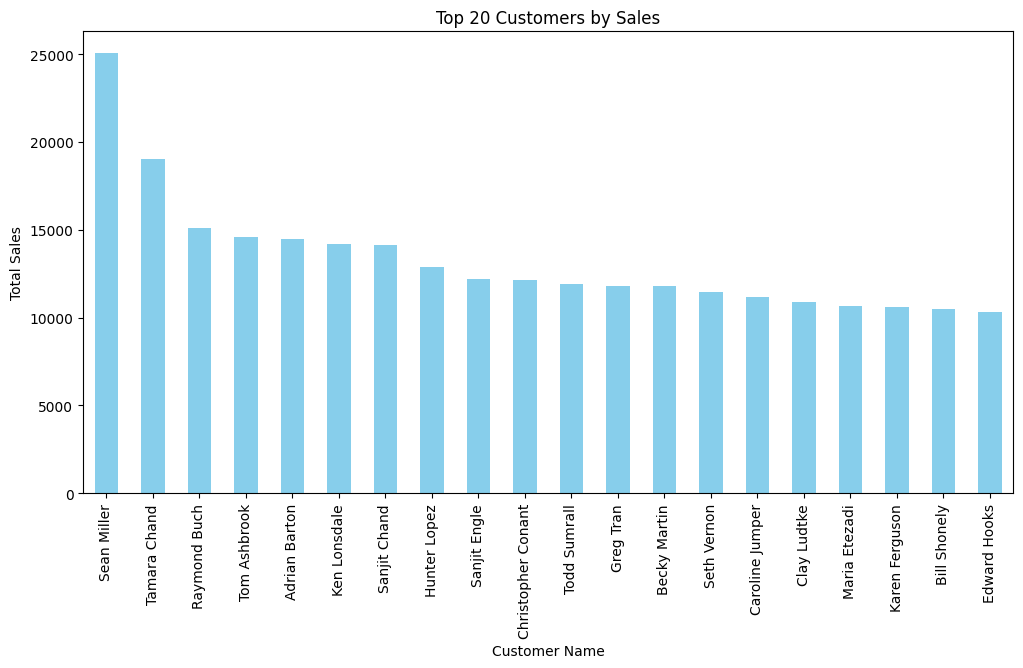

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
top20_customers_sales.plot(kind="bar", color="skyblue")
plt.title("Top 20 Customers by Sales")
plt.ylabel("Total Sales")
plt.xlabel("Customer Name")
plt.xticks(rotation=90)
plt.show()


In [23]:
#Plot the Cumulative curve in Sales by Customers.
customer_sales = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False)

cumulative_sales = customer_sales.cumsum() / customer_sales.sum()


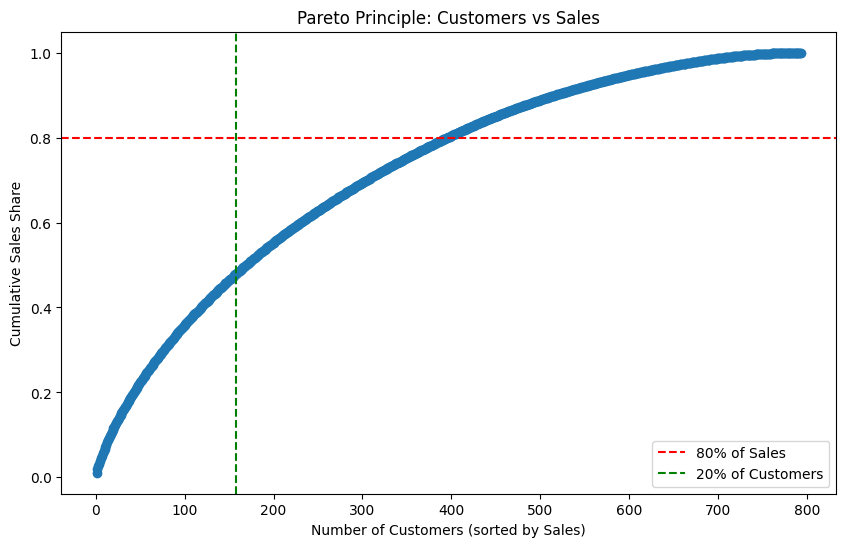

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(range(1, len(customer_sales)+1), cumulative_sales.values, marker="o")
plt.axhline(0.8, color="red", linestyle="--", label="80% of Sales")
plt.axvline(int(len(customer_sales)*0.2), color="green", linestyle="--", label="20% of Customers")
plt.title("Pareto Principle: Customers vs Sales")
plt.xlabel("Number of Customers (sorted by Sales)")
plt.ylabel("Cumulative Sales Share")
plt.legend()
plt.show()


**Interpret the Curve**

If the curve shows that ~20% of customers reach ~80% of cumulative sales, then the Pareto Principle holds.

If it takes more than 20% of customers to reach 80% of sales, then sales are more evenly distributed.

If fewer than 20% of customers already reach 80%, then sales are highly concentrated among a small group.

**Executive Marketing Strategy Report**

Marketing resources should be concentrated on New York, California, and profit-strong cities like Miami, Dallas, and Seattle, while nurturing the top 20% of customers who drive the majority of revenue and profit. This dual focus ensures both growth and efficiency in marketing strategy.